# 1. Imports

In [12]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import librosa.display
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# Merging audio with trainset

In [8]:
train = pd.read_csv(f"data/train.csv")
test = pd.read_csv(f"data/test.csv")

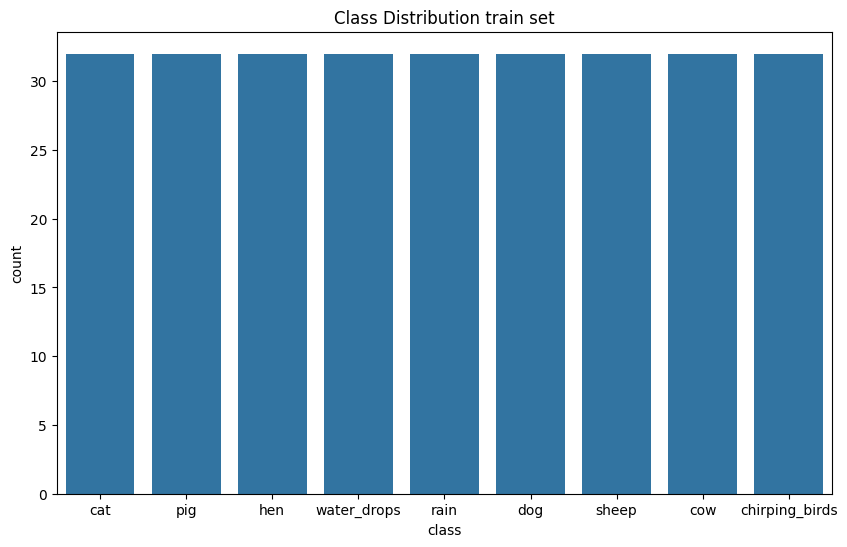

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=train, x='class')
plt.title("Class Distribution train set")
plt.show()

In [19]:
import librosa, numpy as np, tensorflow as tf, tensorflow_hub as hub

# Load YAMNet model
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

def extract_handcrafted(file_path):
    y, sr = librosa.load(file_path, sr=44100, mono=True, duration=5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfcc_mean, mfcc_std = np.mean(mfcc, axis=1), np.std(mfcc, axis=1)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    rms = np.mean(librosa.feature.rms(y=y))
    return np.concatenate([mfcc_mean, mfcc_std, mfcc_delta_mean,
                           [spec_centroid, spec_rolloff, spec_bandwidth, zcr, rms],
                           chroma])

def extract_yamnet(file_path):
    y, sr = librosa.load(file_path, sr=16000, mono=True)
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)
    _, embeddings, _ = yamnet_model(waveform)
    return np.mean(embeddings.numpy(), axis=0)

def extract_features(file_path):
    return np.concatenate([extract_handcrafted(file_path), extract_yamnet(file_path)])

ModuleNotFoundError: No module named 'pkg_resources'

In [16]:
X, y = [], []
for index, row in train.iterrows():
    features = extract_features(f"data/{row['sampleID']}.wav")
    X.append(features)
    y.append(row['class'])

NameError: name 'extract_handcrafted' is not defined